<a href="https://colab.research.google.com/github/AnkitKolte47/Syandrix_Infotech_Task/blob/main/Titanic_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("../data/train.csv")

In [ ]:
df.head()

df.shape

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [ ]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [ ]:
df.drop(columns=["Cabin"], inplace=True)

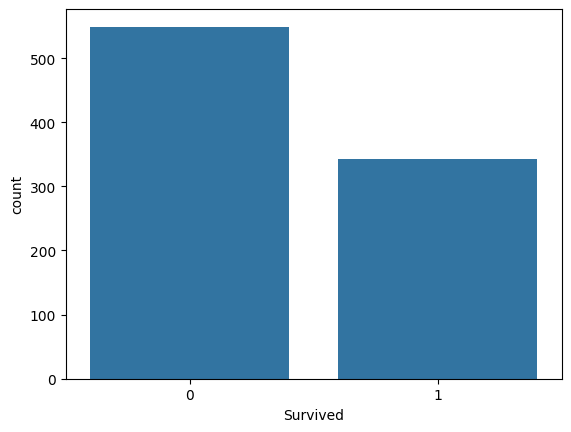

In [ ]:
sns.countplot(x="Survived", data=df)
plt.show()

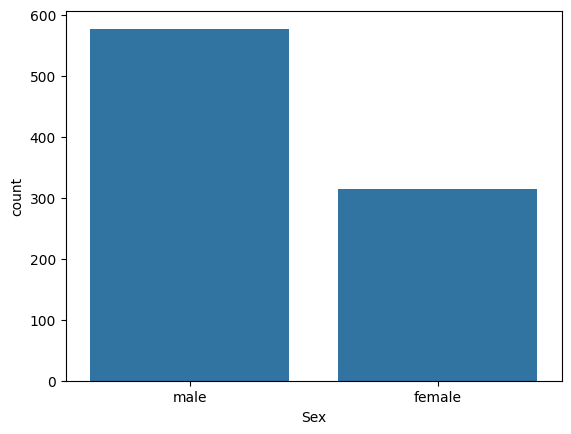

In [ ]:
sns.countplot(x="Sex", data=df)
plt.show()

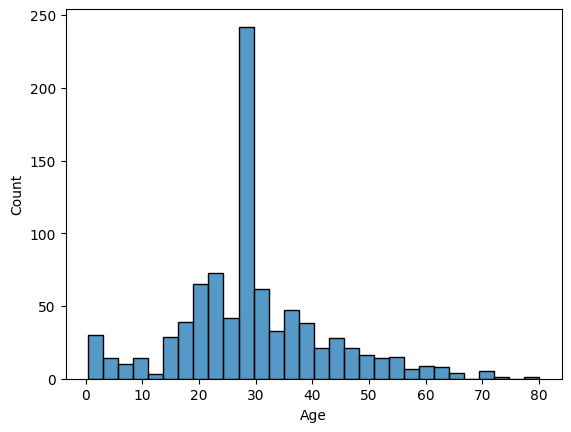

In [ ]:
sns.histplot(df["Age"], bins=30)
plt.show()

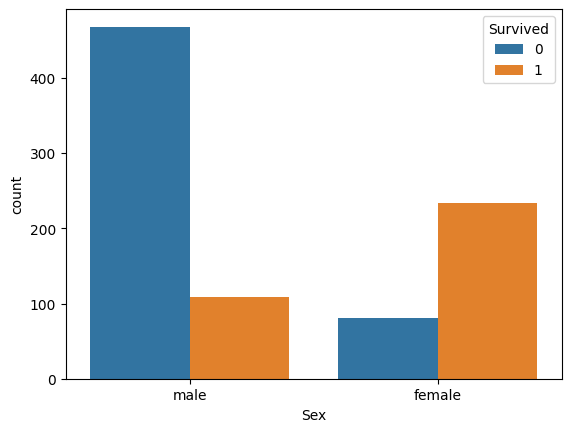

In [ ]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.show()

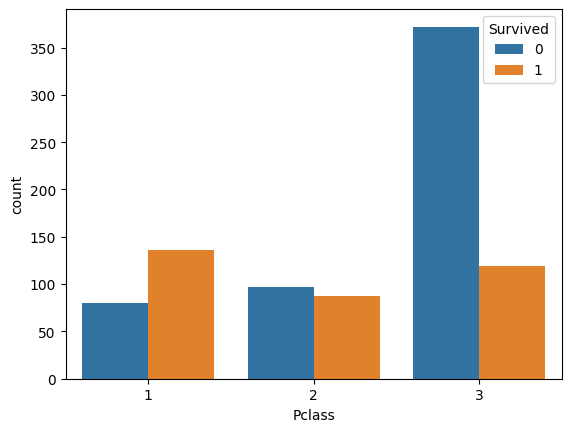

In [ ]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.show()

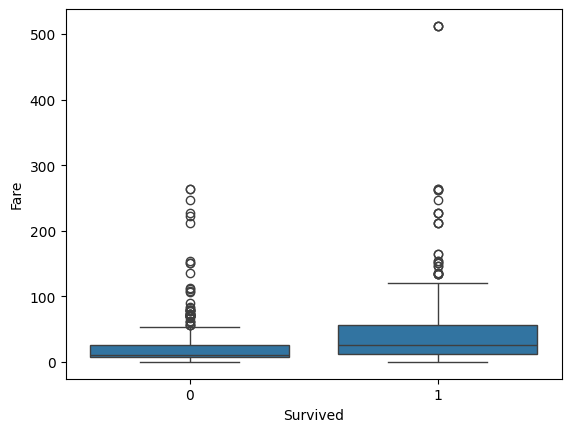

In [ ]:
sns.boxplot(x="Survived", y="Fare", data=df)
plt.show()

In [ ]:
df["Sex"] = df["Sex"].map({
    "male":0,
    "female":1
})

df["Embarked"] = df["Embarked"].map({
    "S":0,
    "C":1,
    "Q":2
})

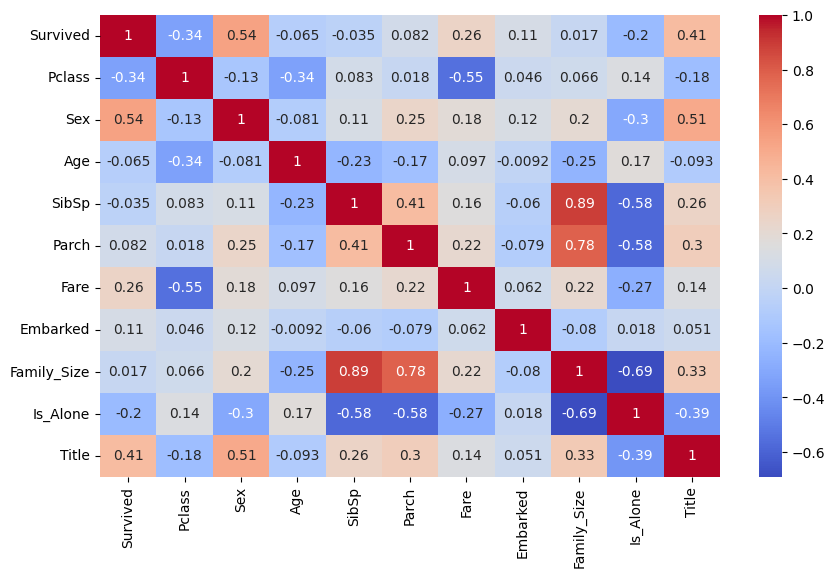

In [ ]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [ ]:
df["Family_Size"] = (
    df["SibSp"] + df["Parch"] + 1
)

In [ ]:
df["Is_Alone"] = np.where(
    df["Family_Size"] == 1,
    1,
    0
)

In [ ]:
df["Title"] = df["Name"].str.extract(
    ' ([A-Za-z]+)\.',
    expand=False
)

In [ ]:
df["Title"].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [ ]:
title_map = {
    "Mr":0,
    "Miss":1,
    "Mrs":2,
    "Master":3
}

df["Title"] = df["Title"].map(title_map)

df["Title"] = df["Title"].fillna(4)

In [ ]:
df.drop(
    columns=["PassengerId", "Name", "Ticket"],
    inplace=True
)

In [ ]:
features = df.drop("Survived", axis=1)

target = df["Survived"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
clean_df = pd.concat(
    [features, target],
    axis=1
)

clean_df.to_csv(
    "../data/clean_titanic.csv",
    index=False
)